--- COP32 Regional Climate Summary ---
    Country  Avg Temp (°C)  Max Temp (°C)  Total Annual Rain (mm)  \
0  Ethiopia          16.07          30.93                 1243.97   
1   Nigeria          26.66          32.88                 1442.56   
2     Kenya          20.43          34.27                  502.60   
3     Sudan          28.76          45.96                  220.42   
4  Tanzania          26.80          33.93                 1280.41   

   Humidity-Temp Corr  
0               -0.19  
1               -0.04  
2               -0.59  
3                0.04  
4                0.12  


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5320\2399040613.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Country', y='Avg Temp (°C)', palette='YlOrRd')


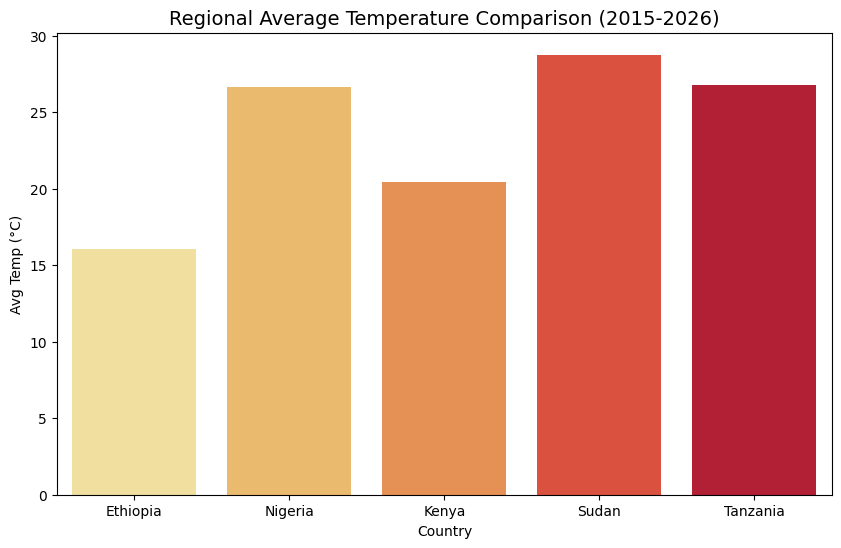

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# List of your cleaned files
countries = ['ethiopia', 'nigeria', 'kenya', 'sudan', 'tanzania']
summary_data = []

for country in countries:
    # Load each cleaned file
    temp_df = pd.read_csv(f"data/{country}_clean.csv")
    
    # Calculate key metrics for COP32 report
    stats = {
        'Country': country.replace('_', ' ').title(),
        'Avg Temp (°C)': round(temp_df['T2M'].mean(), 2),
        'Max Temp (°C)': round(temp_df['T2M_MAX'].max(), 2),
        'Total Annual Rain (mm)': round(temp_df.groupby('YEAR')['PRECTOTCORR'].sum().mean(), 2),
        'Humidity-Temp Corr': round(temp_df['T2M'].corr(temp_df['RH2M']), 2)
    }
    summary_data.append(stats)

# Create the Summary Table
comparison_df = pd.DataFrame(summary_data)
print("--- COP32 Regional Climate Summary ---")
print(comparison_df)

# Visualizing the difference in Average Temperature
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Country', y='Avg Temp (°C)', palette='YlOrRd')
plt.title('Regional Average Temperature Comparison (2015-2026)', fontsize=14)
plt.show()

The regional analysis confirms that Sudan faces the highest thermal risk with average temperatures near $29°C$ and extremes hitting $46°C$. Nigeria represents the highest flood risk with the highest annual precipitation ($1442$ mm), while Ethiopia remains a climatic outlier due to its high altitude, maintaining the lowest average temperature in the study group ($16.07°C$).